In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr
import os

#to get font to work
font_dir = os.path.expanduser("/home/mbrannon/.fonts")
font_files = fm.findSystemFonts(fontpaths=[font_dir])
for font_file in font_files:
    fm.fontManager.addfont(font_file)
plt.rcParams["font.family"] = "IBM Plex Sans"
rcParams["font.sans-serif"] = ["IBM Plex Sans"]


#### Single Cell correlation plot

In [60]:
#This file is an output from running predict_cell_type from vinson
cor_df = pd.read_table("/home/mbrannon/tmp/ag_preds_mouse/AG10430.predictions.tsv")

In [61]:
cor_df

,chrom,start,end,target_counts,pred_counts,log_target_counts,log_pred_counts
0,chr1,4769946,4770186,14.999999,13.740350,2.772589,2.690589
1,chr1,4780154,4780379,32.999999,15.649184,3.526360,2.812361
2,chr1,4785643,4785885,75.000003,7.377078,4.330733,2.125499
3,chr1,4807482,4807703,47.000000,10.671665,3.871201,2.457164
4,chr1,4807703,4807841,31.000000,15.332529,3.465736,2.793159
...,...,...,...,...,...,...,...
81433,chrY,1284919,1285281,7.000000,8.670474,2.079442,2.269077
81434,chrY,1286006,1286230,32.000001,31.662775,3.496508,3.486236
81435,chrY,1286486,1286727,268.999991,97.833608,5.598422,4.593438
81436,chrY,1293801,1294079,39.000001,11.824064,3.688879,2.551323


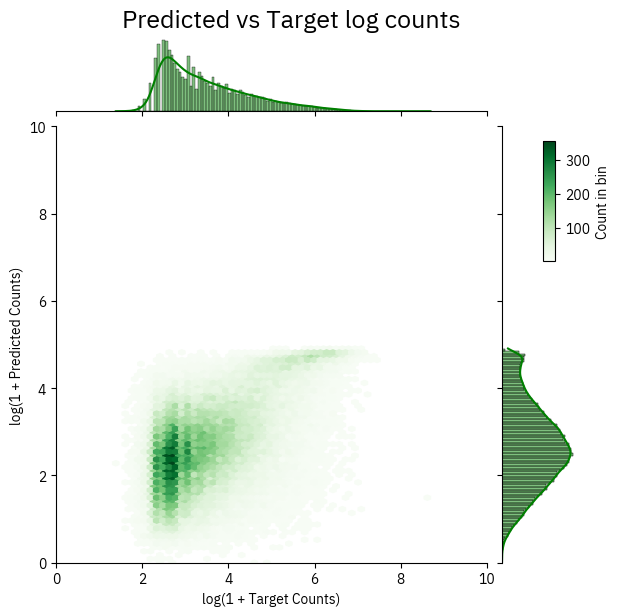

In [62]:
#plot log target read counts vs log predicted read counts

plot = sns.jointplot(
    x="log_target_counts", 
    y="log_pred_counts", 
    data=cor_df,
    kind='hex',
    cmap = 'Greens',
    marginal_kws=dict(color = 'Green', kde=True),
    height=6,
    gridsize=50,
    mincnt=1
)

plot.ax_joint.set_xlim(0, 10)   # adjust to your data range
plot.ax_joint.set_ylim(0, 10)

#optional:put pearson in title
# pearson_density_r, _ = pearsonr(cor_df["log_target_counts"], cor_df["log_pred_counts"])
# plot.fig.suptitle(f"Log(Predicted) vs Log(Target) counts \nPearson r = {pearson_density_r:.3f}", y=1.02)
plot.fig.suptitle("Predicted vs Target log counts", fontsize=18, y=1.02)

# Axis labels
plot.set_axis_labels("log(1 + Target Counts)", "log(1 + Predicted Counts)")

#colorbar position
cbar_ax = plot.fig.add_axes([.92, .6, .02, .2])
plt.colorbar(plot.ax_joint.collections[0], cax=cbar_ax, label="Count in bin")

plt.show()


#### Validation Data Correlation Plot

In [30]:
#file comes from vinsion predict.py
headers = [
    "chrom",
    "mid",
    "embedding_id",
    "predicted_counts",
    "target_counts",
    "pred_total_density",
    "obs_total_density"
]
df = pd.read_table('/home/mbrannon/tmp/preds/AUG3_with_warmup_and_decay_prediction_merged.tsv',sep="\t", header=None, names=headers)
#convert from tensor
df["mid"] = df["mid"].astype(str).str.replace(r"tensor\(|\)", "", regex=True).astype(int)


In [31]:
df

,chrom,mid,embedding_id,predicted_counts,target_counts,pred_total_density,obs_total_density
0,chr22,tensor(15384375),AG72439,3.130609,0.000000,0.021194,0.000000
1,chr22,tensor(15384375),AG80473,5.527286,1.999989,0.157520,0.056997
2,chr22,tensor(15384375),AG80672,5.016570,0.000000,0.113429,0.000000
3,chr22,tensor(15420187),AG72755,4.037259,4.999960,0.017216,0.021321
4,chr22,tensor(15420187),AG80606,0.546457,0.000000,0.027349,0.000000
...,...,...,...,...,...,...,...
18329339,chr9,tensor(99999088),AG80578,4.746764,7.000005,0.164717,0.242907
18329340,chr9,tensor(99999088),AG80620,8.100182,1.000032,0.128651,0.015883
18329341,chr9,tensor(99999088),AG80646,2.350875,0.999988,0.091046,0.038728
18329342,chr9,tensor(99999088),AG93570,19.181080,0.999931,0.113502,0.005917


In [38]:
# Apply log transformation (handles 0s safely)
df["log_pred_total_density"] = np.log(df["pred_total_density"]+1e6)
df["log_obs_total_density"] = np.log(df["obs_total_density"]+1e6)

In [39]:
# Calculate Pearson correlation in log-space
r, p = pearsonr(df["log_obs_total_density"], df["log_pred_total_density"])

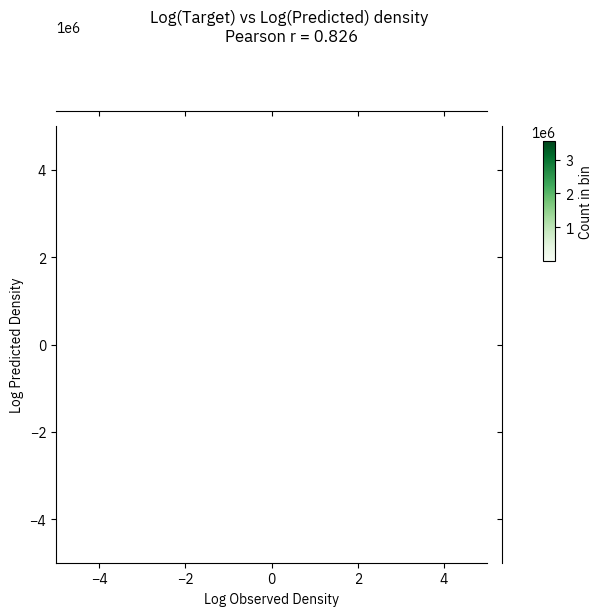

In [45]:
#plot log target read counts vs log predicted read counts

plot = sns.jointplot(
    x="log_obs_total_density", 
    y="log_pred_total_density", 
    data=df,
    kind='hex',
    cmap = 'Greens',
    marginal_kws=dict(color = 'Green', kde=True),
    height=6,
    gridsize=50,
    mincnt=1
)

plot.ax_joint.set_xlim(-5, 5)   
plot.ax_joint.set_ylim(-5, 5)

plot.fig.suptitle(f"Log(Target) vs Log(Predicted) density \nPearson r = {r:.3f}", y=1.02)

# Axis labels
plot.set_axis_labels("Log Observed Density", "Log Predicted Density")

#colorbar position
cbar_ax = plot.fig.add_axes([.92, .6, .02, .2])
plt.colorbar(plot.ax_joint.collections[0], cax=cbar_ax, label="Count in bin")

plt.show()


In [43]:
df["log_predicted"] = np.log1p(df["predicted_counts"])
df["log_target"] = np.log1p(df["target_counts"])
r, p = pearsonr(df["log_predicted"], df["log_target"])


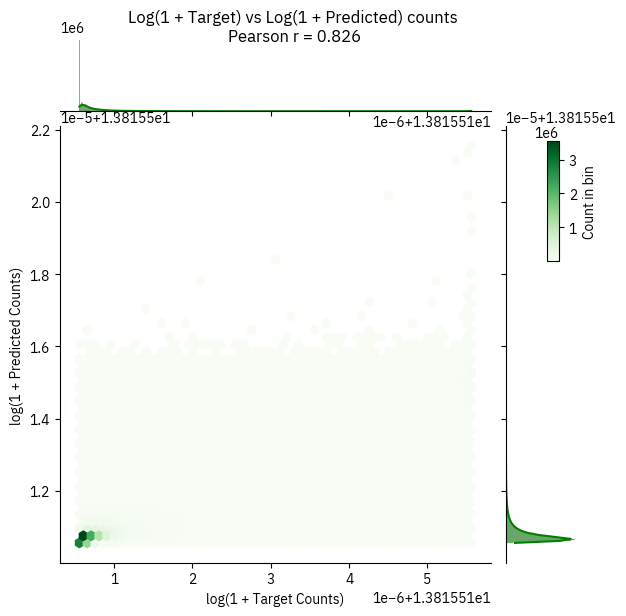

In [44]:
#plot log target read counts vs log predicted read counts

plot = sns.jointplot(
    x="log_obs_total_density", 
    y="log_pred_total_density", 
    data=df,
    kind='hex',
    cmap = 'Greens',
    marginal_kws=dict(color = 'Green', kde=True),
    height=6,
    gridsize=50,
    mincnt=1
)

# plot.ax_joint.set_xlim(0, 10)   
# plot.ax_joint.set_ylim(0, 10)

plot.fig.suptitle(f"Log(1 + Target) vs Log(1 + Predicted) counts \nPearson r = {r:.3f}", y=1.02)

# Axis labels
plot.set_axis_labels("log(1 + Target Counts)", "log(1 + Predicted Counts)")

#colorbar position
cbar_ax = plot.fig.add_axes([.92, .6, .02, .2])
plt.colorbar(plot.ax_joint.collections[0], cax=cbar_ax, label="Count in bin")

plt.show()


In [46]:
df

,chrom,mid,embedding_id,predicted_counts,target_counts,pred_total_density,obs_total_density,log_pred_total_density,log_obs_total_density,log_predicted,log_target
0,chr22,15384375,AG72439,3.130609,0.000000,0.021194,0.000000,13.815511,13.815511,1.418425,0.000000
1,chr22,15384375,AG80473,5.527286,1.999989,0.157520,0.056997,13.815511,13.815511,1.875991,1.098609
2,chr22,15384375,AG80672,5.016570,0.000000,0.113429,0.000000,13.815511,13.815511,1.794517,0.000000
3,chr22,15420187,AG72755,4.037259,4.999960,0.017216,0.021321,13.815511,13.815511,1.616862,1.791753
4,chr22,15420187,AG80606,0.546457,0.000000,0.027349,0.000000,13.815511,13.815511,0.435966,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
18329339,chr9,99999088,AG80578,4.746764,7.000005,0.164717,0.242907,13.815511,13.815511,1.748637,2.079442
18329340,chr9,99999088,AG80620,8.100182,1.000032,0.128651,0.015883,13.815511,13.815511,2.208294,0.693163
18329341,chr9,99999088,AG80646,2.350875,0.999988,0.091046,0.038728,13.815511,13.815511,1.209222,0.693141
18329342,chr9,99999088,AG93570,19.181080,0.999931,0.113502,0.005917,13.815511,13.815511,3.004746,0.693113
